# Laboratorio 7 – Spark MLlib (AVANCE)
**CC3066 – Data Science · Semestre II – 2026 · Universidad del Valle de Guatemala**

**Integrantes:** Jonathan Zacarias 231104 
**Repositorio Git:** 

Este notebook cubre el **avance**: carga y calidad de datos (ej. 1), estadística descriptiva (ej. 2), correlaciones (ej. 3) y segmentación con KMeans (ej. 4) sobre las bases de Personas de la ENEIC 2025.



> **Alcance:** los resultados describen a los **registros analizados** (no ponderados). No son estimaciones oficiales de la población guatemalteca ni relaciones causales.

## 0. Configuración y sesión de Spark

In [1]:
!pip install openpyxl --user

In [2]:
import os, math, warnings
from functools import reduce
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pyspark.sql import SparkSession, functions as F, types as T
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.stat import Correlation
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50, "display.width", 200)

spark = (SparkSession.builder
         .appName("Lab7_ENEIC")
         .config("spark.driver.memory", "4g")
         .config("spark.sql.shuffle.partitions", "8")
         .getOrCreate())
spark.sparkContext.setLogLevel("ERROR")
print("Spark", spark.version)

/usr/local/lib/python3.11/site-packages/pyspark/bin/load-spark-env.sh: line 68: ps: command not found
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/24 22:40:35 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark 3.5.1


In [3]:
# ===================== CONFIGURACIÓN (EDITAR) =====================
# periodo_archivo -> ruta del archivo de Personas (Excel .xlsx o .csv)
ARCHIVOS = {
    "2025T1": "./data/Personas_ENEIC_T1_2025.xlsx",
    "2025T2": "./data/Personas-ENEIC-T2-2025.xlsx",
    "2025T3": "./data/Base-de-datos-Personas-ENEIC-III-2025.xlsx",
    "2025T4": "./data/Base-de-datos-Personas-ENEIC-IV-2025.xlsx",
    "2026T1": "./data/Base-de-datos-Personas-ENEIC-I-2026.xlsx",
}
PERIODOS_2025 = ["2025T1", "2025T2", "2025T3", "2025T4"]
PERIODO_2026  = "2026T1"

DIR_STAGE = "./data/parquet/stage"      # una carpeta Parquet por archivo (columnas seleccionadas)
DIR_OUT   = "./data/parquet"            # conjuntos preparados 2025 y 2026
SEED = 42

# Códigos válidos según el diccionario. Si se deja en None se toman los códigos numéricos
# observados en 2025 (y se imprimen para que los contraste con el diccionario).
NIVEL_VALIDOS   = None   # ej.: {"0","1","2","3","4","5","6","7"}   <- verificar con el diccionario
DOMINIO_VALIDOS = None   # ej.: {"1","2","3","4"}                     <- verificar con el diccionario

CAT_LABELS = {"1": "Gobierno", "2": "Empresa privada", "3": "Jornalero/peón", "4": "Servicio doméstico"}

# Columnas originales que se conservan
COLS_TEXTO = ["NUM_HOGAR", "NUM_PERSONA", "DOMINIO", "P03A03A", "P05C16", "OCUPADOS"]
COLS_NUM   = ["P05D01", "P02A03", "P05C07A", "P05C07B", "P05H01A", "FACTOR", "ANIO", "TRIMESTRE"]
COLS_SEL   = COLS_TEXTO + COLS_NUM
for d in (DIR_STAGE, DIR_OUT): os.makedirs(d, exist_ok=True)

---
# Sección 1 · Análisis exploratorio avanzado y segmentación
## 1. Carga, armonización y calidad de datos
**Estrategia:** cada Excel se lee **individualmente** con pandas (solo las columnas necesarias, para controlar memoria), se normalizan los códigos a texto consistente (un mismo código puede llegar como `2`, `2.0` o `"2"`), se convierte a DataFrame de Spark con **esquema explícito** y se guarda en Parquet. Después todo el trabajo es en Spark.

In [4]:
SCHEMA = T.StructType(
    [T.StructField(c, T.StringType(), True) for c in COLS_TEXTO] +
    [T.StructField(c, T.DoubleType(), True) for c in COLS_NUM]
)

def _norm_codigo(s: pd.Series) -> pd.Series:
    """Texto limpio: quita espacios, '2.0' -> '2', vacíos/nan -> None."""
    s = s.astype(object).where(s.notna(), None)
    s = s.map(lambda v: None if v is None else str(v).strip())
    s = s.str.replace(r"^(-?\d+)\.0+$", r"\1", regex=True)
    return s.where(~s.isin(["", "nan", "NaN", "None", "NULL"]), None)

def leer_a_parquet(periodo: str, ruta: str) -> dict:
    """Lee un archivo, homologa tipos, escribe Parquet y devuelve métricas de auditoría."""
    ext = os.path.splitext(ruta)[1].lower()
    filtro = lambda c: str(c).strip().upper() in COLS_SEL
    if ext in (".xlsx", ".xlsm", ".xls"):
        n_cols = pd.read_excel(ruta, nrows=0).shape[1]
        pdf = pd.read_excel(ruta, usecols=filtro, engine="openpyxl")
    else:
        n_cols = pd.read_csv(ruta, nrows=0).shape[1]
        pdf = pd.read_csv(ruta, usecols=filtro, low_memory=False)
    pdf.columns = [str(c).strip().upper() for c in pdf.columns]
    faltan = [c for c in COLS_SEL if c not in pdf.columns]
    if faltan:
        raise ValueError(f"{periodo}: faltan columnas {faltan}")
    pdf = pdf[COLS_SEL]

    for c in COLS_TEXTO:
        pdf[c] = _norm_codigo(pdf[c])
    for c in COLS_NUM:
        pdf[c] = pd.to_numeric(pdf[c], errors="coerce").astype("float64")
        pdf[c] = pdf[c].astype(object).where(pdf[c].notna(), None)   # NaN -> null

    sdf = spark.createDataFrame(pdf.astype(object).where(pdf.notna(), None), schema=SCHEMA)
    (sdf.write.mode("overwrite").parquet(f"{DIR_STAGE}/{periodo}"))
    return {"periodo_archivo": periodo, "archivo_origen": os.path.basename(ruta),
            "registros_originales": len(pdf), "columnas_originales": n_cols}

auditoria_carga = []
for per, ruta in ARCHIVOS.items():
    print("Procesando", per, "...")
    auditoria_carga.append(leer_a_parquet(per, ruta))
auditoria_carga = pd.DataFrame(auditoria_carga)
auditoria_carga

Procesando 2025T1 ...


Procesando 2025T2 ...
Procesando 2025T3 ...


Procesando 2025T4 ...
Procesando 2026T1 ...


,periodo_archivo,archivo_origen,registros_originales,columnas_originales
0,2025T1,Personas_ENEIC_T1_2025.xlsx,51588,270
1,2025T2,Personas-ENEIC-T2-2025.xlsx,51167,270
2,2025T3,Base-de-datos-Personas-ENEIC-III-2025.xlsx,51583,270
3,2025T4,Base-de-datos-Personas-ENEIC-IV-2025.xlsx,49338,302
4,2026T1,Base-de-datos-Personas-ENEIC-I-2026.xlsx,49843,270


**Nota:** IV de 2025 trae más columnas (302 vs 270) y en un orden que puede diferir. Por eso las bases se combinan **por nombre** (`unionByName`) y no por posición.

In [5]:
def cargar_periodo(per: str):
    """Lee el Parquet de un archivo y agrega columnas de procedencia (no toca TRIMESTRE original)."""
    anio, tri = int(per[:4]), int(per[-1])
    return (spark.read.parquet(f"{DIR_STAGE}/{per}")
            .withColumn("periodo_archivo", F.lit(per))
            .withColumn("anio_archivo", F.lit(anio))
            .withColumn("trimestre_calendario", F.lit(tri))
            .withColumn("archivo_origen", F.lit(os.path.basename(ARCHIVOS[per]))))

df25 = reduce(lambda a, b: a.unionByName(b), [cargar_periodo(p) for p in PERIODOS_2025]).cache()
df26 = cargar_periodo(PERIODO_2026).cache()
print("Registros 2025 (4 archivos):", df25.count(), "| Registros 2026:", df26.count())
df25.printSchema()
df25.show(5, truncate=False)

Registros 2025 (4 archivos): 203676 | Registros 2026: 49843
root
 |-- NUM_HOGAR: string (nullable = true)
 |-- NUM_PERSONA: string (nullable = true)
 |-- DOMINIO: string (nullable = true)
 |-- P03A03A: string (nullable = true)
 |-- P05C16: string (nullable = true)
 |-- OCUPADOS: string (nullable = true)
 |-- P05D01: double (nullable = true)
 |-- P02A03: double (nullable = true)
 |-- P05C07A: double (nullable = true)
 |-- P05C07B: double (nullable = true)
 |-- P05H01A: double (nullable = true)
 |-- FACTOR: double (nullable = true)
 |-- ANIO: double (nullable = true)
 |-- TRIMESTRE: double (nullable = true)
 |-- periodo_archivo: string (nullable = false)
 |-- anio_archivo: integer (nullable = false)
 |-- trimestre_calendario: integer (nullable = false)
 |-- archivo_origen: string (nullable = false)

+---------+-----------+-------+-------+------+--------+------+------+-------+-------+-------+------+------+---------+---------------+------------+--------------------+------------------------

In [6]:
# Auditoría del campo TRIMESTRE original (se conserva, no se usa como trimestre calendario)
(df25.unionByName(df26).groupBy("periodo_archivo", "TRIMESTRE").count()
     .orderBy("periodo_archivo", "TRIMESTRE").show())

[Stage 19:===========================================>          (80 + 20) / 100]

+---------------+---------+-----+
|periodo_archivo|TRIMESTRE|count|
+---------------+---------+-----+
|         2025T1|      2.0|51588|
|         2025T2|      2.0|  175|
|         2025T2|      3.0|50992|
|         2025T3|      4.0|51583|
|         2025T4|      5.0|49338|
|         2026T1|      6.0|49843|
+---------------+---------+-----+



### 1.1 Faltantes por variable (antes de aplicar filtros)

In [7]:
def faltantes(df, cols_txt, cols_num):
    n = df.count()
    exprs = []
    for c in cols_txt:
        exprs.append(F.sum(F.when(F.col(c).isNull(), 1).otherwise(0)).alias(c))
    for c in cols_num:
        exprs.append(F.sum(F.when(F.col(c).isNull() | F.isnan(c), 1).otherwise(0)).alias(c))
    fila = df.agg(*exprs).first().asDict()
    out = pd.DataFrame({"variable": list(fila.keys()), "faltantes": list(fila.values())})
    out["pct_faltantes"] = (100 * out["faltantes"] / n).round(2)
    return out

falt25 = faltantes(df25, COLS_TEXTO, COLS_NUM)
falt25

,variable,faltantes,pct_faltantes
0,NUM_HOGAR,0,0.00
1,NUM_PERSONA,0,0.00
2,DOMINIO,0,0.00
3,P03A03A,26344,12.93
4,P05C16,115454,56.69
5,OCUPADOS,115454,56.69
6,P05D01,150651,73.97
7,P02A03,0,0.00
8,P05C07A,115454,56.69
9,P05C07B,115454,56.69


In [8]:
# Faltantes por archivo (para detectar si algún archivo concentra los vacíos)
partes = []
for p in PERIODOS_2025 + [PERIODO_2026]:
    d = (df25 if p in PERIODOS_2025 else df26).filter(F.col("periodo_archivo") == p)
    t = faltantes(d, COLS_TEXTO, COLS_NUM).set_index("variable")["pct_faltantes"].rename(p)
    partes.append(t)
pd.concat(partes, axis=1)

,2025T1,2025T2,2025T3,2025T4,2026T1
variable,,,,,
NUM_HOGAR,0.00,0.00,0.00,0.00,0.00
NUM_PERSONA,0.00,0.00,0.00,0.00,0.00
DOMINIO,0.00,0.00,0.00,0.00,0.00
P03A03A,13.43,13.05,12.69,12.55,12.06
P05C16,56.83,56.33,56.63,56.96,56.40
OCUPADOS,56.83,56.33,56.63,56.96,56.40
P05D01,73.99,73.63,73.93,74.33,73.40
P02A03,0.00,0.00,0.00,0.00,0.00
P05C07A,56.83,56.33,56.63,56.96,56.40


**Interpretación de faltantes.** _(Complete tras ejecutar: cuáles variables tienen más vacíos y si el patrón es distinto por archivo. Recuerde que en `P05D01`, `P05C07A/B` y `P05H01A` un vacío suele significar que la persona **no es asalariada/ocupada** y la pregunta no le corresponde; ver respuestas conceptuales al final de la sección.)_

### 1.2 Construcción de variables analíticas y reglas de preparación
Las reglas se aplican **siempre en el mismo orden** y se contabilizan los excluidos en cada paso, separando los que **no pudieron evaluarse** (dato nulo/no numérico) de los que **incumplen** el criterio. El salario **no se imputa**.

Orden de filtrado:
1. Edad finita y ≥ 15 · 2. `OCUPADOS = 1` · 3. `P05C16 ∈ {1,2,3,4}` · 4. Salario finito y > 0 · 5. Antigüedad evaluable (años y meses presentes) · 6. Meses entero entre 0 y 11 · 7. Años de antigüedad ≥ 0 · 8. Antigüedad total ≤ edad · 9. Horas habituales > 0 y ≤ 168.

In [9]:
def es_finito(c):   # numérico no nulo, no NaN, no infinito
    col = F.col(c)
    return col.isNotNull() & ~F.isnan(col) & (F.abs(col) != float("inf"))

def con_variables_analiticas(df):
    return (df
        .withColumn("salario_mensual", F.col("P05D01"))
        .withColumn("edad", F.col("P02A03"))
        .withColumn("antiguedad_anios", F.col("P05C07A"))
        .withColumn("antiguedad_meses", F.col("P05C07B"))
        .withColumn("antiguedad", F.col("P05C07A") + F.col("P05C07B") / 12.0)
        .withColumn("horas_semanales", F.col("P05H01A"))
        .withColumn("ocupado", F.col("OCUPADOS"))
        .withColumn("nivel_raw", F.col("P03A03A"))
        .withColumn("categoria_raw", F.col("P05C16"))
        .withColumn("dominio_raw", F.col("DOMINIO")))

# (nombre, condición, columnas de entrada [(col, 'num'|'str')])
PASOS = [
    ("1. edad finita y >= 15",           es_finito("edad") & (F.col("edad") >= 15), [("edad","num")]),
    ("2. ocupado = 1",                   F.col("ocupado") == "1",                    [("ocupado","str")]),
    ("3. P05C16 en {1,2,3,4}",           F.col("categoria_raw").isin("1","2","3","4"), [("categoria_raw","str")]),
    ("4. salario finito y > 0",          es_finito("salario_mensual") & (F.col("salario_mensual") > 0), [("salario_mensual","num")]),
    ("5. antigüedad evaluable (años y meses)", es_finito("antiguedad_anios") & es_finito("antiguedad_meses"),
                                         [("antiguedad_anios","num"),("antiguedad_meses","num")]),
    ("6. meses entero en [0, 11]",       (F.col("antiguedad_meses") >= 0) & (F.col("antiguedad_meses") <= 11) &
                                         (F.col("antiguedad_meses") == F.floor("antiguedad_meses")), [("antiguedad_meses","num")]),
    ("7. antigüedad (años) >= 0",        F.col("antiguedad_anios") >= 0,             [("antiguedad_anios","num")]),
    ("8. antigüedad <= edad",            F.col("antiguedad") <= F.col("edad"),       [("antiguedad","num"),("edad","num")]),
    ("9. horas en (0, 168]",             es_finito("horas_semanales") & (F.col("horas_semanales") > 0) & (F.col("horas_semanales") <= 168),
                                         [("horas_semanales","num")]),
]

def _nulo(col, tipo):
    return F.col(col).isNull() | (F.isnan(col) if tipo == "num" else F.lit(False))

def aplicar_filtros(df, pasos=PASOS, verbose=True):
    """Aplica los pasos en orden. Devuelve (df filtrado, tabla de conteos por paso y archivo)."""
    actual = con_variables_analiticas(df)
    filas = []
    for nombre, cond, ins in pasos:
        c = F.coalesce(cond, F.lit(False))
        nulo_any = reduce(lambda a, b: a | b, [_nulo(cn, t) for cn, t in ins])
        r = (actual.groupBy("periodo_archivo")
                   .agg(F.count("*").alias("entran"),
                        F.sum(F.when(~c, 1).otherwise(0)).alias("excluidos"),
                        F.sum(F.when(~c & nulo_any, 1).otherwise(0)).alias("no_evaluables"))
                   .toPandas())
        r.insert(0, "paso", nombre)
        filas.append(r)
        actual = actual.filter(c)
    tabla = pd.concat(filas, ignore_index=True)
    return actual, tabla

def normalizar_categoricas(df, nivel_validos, dominio_validos):
    def val(colname, validos):
        c = F.col(colname)
        return F.when(c.isNotNull() & c.isin(*sorted(validos)), c).otherwise(F.lit("DESCONOCIDO"))
    return (df
        .withColumn("nivel_educativo", val("nivel_raw", nivel_validos))
        .withColumn("categoria_ocupacional", val("categoria_raw", {"1","2","3","4"}))
        .withColumn("dominio", val("dominio_raw", dominio_validos)))

In [10]:
# Códigos observados (en 2025) para contrastar contra el diccionario de datos
for c in ["P03A03A", "DOMINIO", "P05C16", "OCUPADOS"]:
    print(f"--- {c} ---")
    df25.groupBy(c).count().orderBy(c).show(50, truncate=False)

--- P03A03A ---
+-------+-----+
|P03A03A|count|
+-------+-----+
|NULL   |26344|
|0      |23751|
|1      |7169 |
|2      |75495|
|3      |24655|
|4      |33959|
|5      |11158|
|6      |1053 |
|7      |92   |
+-------+-----+

--- DOMINIO ---
+-------+-----+
|DOMINIO|count|
+-------+-----+
|1      |67521|
|2      |78570|
|3      |57585|
+-------+-----+

--- P05C16 ---
+------+------+
|P05C16|count |
+------+------+
|NULL  |115454|
|1     |6575  |
|2     |28702 |
|3     |13842 |
|4     |3906  |
|5     |20951 |
|6     |2624  |
|7     |6746  |
|8     |418   |
|9     |4458  |
+------+------+

--- OCUPADOS ---
+--------+------+
|OCUPADOS|count |
+--------+------+
|NULL    |115454|
|1       |88222 |
+--------+------+



In [11]:
def _observados(df, col):
    return {r[0] for r in df.select(col).where(F.col(col).rlike(r"^-?\d+$")).distinct().collect()}

if NIVEL_VALIDOS is None:
    NIVEL_VALIDOS = _observados(df25, "P03A03A")
    print("⚠ NIVEL_VALIDOS tomado de lo observado (confirme con el diccionario):", sorted(NIVEL_VALIDOS))
if DOMINIO_VALIDOS is None:
    DOMINIO_VALIDOS = _observados(df25, "DOMINIO")
    print("⚠ DOMINIO_VALIDOS tomado de lo observado (confirme con el diccionario):", sorted(DOMINIO_VALIDOS))

⚠ NIVEL_VALIDOS tomado de lo observado (confirme con el diccionario): ['0', '1', '2', '3', '4', '5', '6', '7']
⚠ DOMINIO_VALIDOS tomado de lo observado (confirme con el diccionario): ['1', '2', '3']


In [12]:
# ---- Filtros 2025 ----
f25, tabla_pasos25 = aplicar_filtros(df25)
base25 = normalizar_categoricas(f25, NIVEL_VALIDOS, DOMINIO_VALIDOS)

# ---- Filtros 2026 (mismas reglas y mismos códigos válidos definidos con 2025) ----
f26, tabla_pasos26 = aplicar_filtros(df26)
base26 = normalizar_categoricas(f26, NIVEL_VALIDOS, DOMINIO_VALIDOS)

def resumen_pasos(t):
    piv = t.pivot(index="paso", columns="periodo_archivo", values="excluidos").fillna(0).astype(int)
    piv["TOTAL"] = piv.sum(axis=1)
    return piv

print("Registros EXCLUIDOS por paso (mismo orden de filtrado)")
display(resumen_pasos(tabla_pasos25))
print("De los excluidos: cuántos NO pudieron evaluarse por dato nulo/no numérico")
display(tabla_pasos25.pivot(index="paso", columns="periodo_archivo", values="no_evaluables").fillna(0).astype(int))
print("2026 (prueba final)")
display(resumen_pasos(tabla_pasos26))

Registros EXCLUIDOS por paso (mismo orden de filtrado)


periodo_archivo,2025T1,2025T2,2025T3,2025T4,TOTAL
paso,,,,,
1. edad finita y >= 15,16253,15882,15767,14984,62886
2. ocupado = 1,13062,12942,13443,13121,52568
"3. P05C16 en {1,2,3,4}",8854,8851,8923,8569,35197
4. salario finito y > 0,0,0,0,0,0
5. antigüedad evaluable (años y meses),0,0,0,0,0
"6. meses entero en [0, 11]",0,0,0,0,0
7. antigüedad (años) >= 0,0,0,0,0,0
8. antigüedad <= edad,0,0,0,0,0
"9. horas en (0, 168]",0,0,0,0,0


De los excluidos: cuántos NO pudieron evaluarse por dato nulo/no numérico


periodo_archivo,2025T1,2025T2,2025T3,2025T4
paso,,,,
1. edad finita y >= 15,0,0,0,0
2. ocupado = 1,13062,12942,13443,13121
"3. P05C16 en {1,2,3,4}",0,0,0,0
4. salario finito y > 0,0,0,0,0
5. antigüedad evaluable (años y meses),0,0,0,0
"6. meses entero en [0, 11]",0,0,0,0
7. antigüedad (años) >= 0,0,0,0,0
8. antigüedad <= edad,0,0,0,0
"9. horas en (0, 168]",0,0,0,0


2026 (prueba final)


periodo_archivo,2026T1,TOTAL
paso,,
1. edad finita y >= 15,14803,14803
2. ocupado = 1,13306,13306
"3. P05C16 en {1,2,3,4}",8476,8476
4. salario finito y > 0,0,0
5. antigüedad evaluable (años y meses),0,0
"6. meses entero en [0, 11]",0,0
7. antigüedad (años) >= 0,0,0
8. antigüedad <= edad,0,0
"9. horas en (0, 168]",0,0


In [13]:
# Registros por archivo ANTES y DESPUÉS de los filtros
antes = pd.concat([df25.groupBy("periodo_archivo").count().toPandas(),
                   df26.groupBy("periodo_archivo").count().toPandas()]).rename(columns={"count": "antes_filtros"})
despues = pd.concat([base25.groupBy("periodo_archivo").count().toPandas(),
                     base26.groupBy("periodo_archivo").count().toPandas()]).rename(columns={"count": "despues_filtros"})
conteo_archivos = antes.merge(despues, on="periodo_archivo").merge(
    auditoria_carga[["periodo_archivo", "registros_originales", "columnas_originales"]], on="periodo_archivo")
conteo_archivos["pct_retenido"] = (100 * conteo_archivos["despues_filtros"] / conteo_archivos["antes_filtros"]).round(1)
conteo_archivos.sort_values("periodo_archivo").reset_index(drop=True)

,periodo_archivo,antes_filtros,despues_filtros,registros_originales,columnas_originales,pct_retenido
0,2025T1,51588,13419,51588,270,26.0
1,2025T2,51167,13492,51167,270,26.4
2,2025T3,51583,13450,51583,270,26.1
3,2025T4,49338,12664,49338,302,25.7
4,2026T1,49843,13258,49843,270,26.6


**Interpretación.** _(Complete: qué paso elimina más registros y por qué —lo esperable es que `ocupado = 1` y `P05C16` eliminen a quienes no trabajan o no son asalariados—; cuántos se perdieron por datos no evaluables; si algún archivo retiene proporcionalmente menos.)_

### 1.3 Verificación de unicidad de (`periodo_archivo`, `NUM_HOGAR`, `NUM_PERSONA`)
Si hay llaves repetidas se investiga si son **repeticiones exactas** (misma fila en todas las columnas seleccionadas) o **registros en conflicto** (misma llave, valores distintos). **No se usa `dropDuplicates()`.**

In [14]:
LLAVE = ["periodo_archivo", "NUM_HOGAR", "NUM_PERSONA"]
COLS_HASH = COLS_SEL   # columnas seleccionadas (sin metadatos de procedencia)

def auditar_llaves(df):
    h = F.sha2(F.concat_ws("||", *[F.coalesce(F.col(c).cast("string"), F.lit("<NULL>")) for c in COLS_HASH]), 256)
    g = (df.withColumn("_h", h).groupBy(*LLAVE)
           .agg(F.count("*").alias("filas"), F.countDistinct("_h").alias("versiones")))
    return g

g_all = auditar_llaves(df25.unionByName(df26)).cache()
resumen = (g_all.groupBy("periodo_archivo").agg(
    F.count("*").alias("llaves"),
    F.sum(F.when(F.col("filas") > 1, 1).otherwise(0)).alias("llaves_repetidas"),
    F.sum(F.when((F.col("filas") > 1) & (F.col("versiones") == 1), 1).otherwise(0)).alias("repeticion_exacta"),
    F.sum(F.when((F.col("filas") > 1) & (F.col("versiones") > 1), 1).otherwise(0)).alias("en_conflicto"),
    F.sum(F.col("filas")).alias("filas_totales")).orderBy("periodo_archivo").toPandas())
resumen["llave_unica"] = resumen["llaves_repetidas"] == 0
display(resumen)

nulas = df25.unionByName(df26).filter(F.col("NUM_HOGAR").isNull() | F.col("NUM_PERSONA").isNull()).count()
print("Registros con NUM_HOGAR o NUM_PERSONA nulos:", nulas)

,periodo_archivo,llaves,llaves_repetidas,repeticion_exacta,en_conflicto,filas_totales,llave_unica
0,2025T1,51588,0,0,0,51588,True
1,2025T2,51167,0,0,0,51167,True
2,2025T3,51583,0,0,0,51583,True
3,2025T4,49338,0,0,0,49338,True
4,2026T1,49843,0,0,0,49843,True


[Stage 164:==========================================>          (80 + 20) / 100]

Registros con NUM_HOGAR o NUM_PERSONA nulos: 0


In [15]:
# Ejemplos de llaves repetidas (si existen)
rep = g_all.filter(F.col("filas") > 1)
if rep.count() > 0:
    ej = rep.orderBy(F.desc("versiones")).limit(3).collect()
    for r in ej:
        print("Llave:", r["periodo_archivo"], r["NUM_HOGAR"], r["NUM_PERSONA"], "| filas:", r["filas"], "| versiones distintas:", r["versiones"])
    print("\nFilas de la primera llave:")
    r = ej[0]
    (df25.unionByName(df26).filter((F.col("periodo_archivo")==r["periodo_archivo"]) &
        (F.col("NUM_HOGAR")==r["NUM_HOGAR"]) & (F.col("NUM_PERSONA")==r["NUM_PERSONA"])).show(truncate=False))
else:
    print("No hay llaves repetidas: la combinación es única en todos los archivos.")

No hay llaves repetidas: la combinación es única en todos los archivos.


**Interpretación.** _(Complete: si la llave es única; si no lo es, cuántas son repeticiones exactas vs. conflictos y cómo se trataría cada caso. Limitación: la comparación de "conflicto" solo cubre las columnas seleccionadas, no las 270/302 originales.)_

### 1.4 Guardado en Parquet (2025 y 2026 por separado)

In [16]:
COLS_FINALES = (["periodo_archivo", "anio_archivo", "trimestre_calendario", "archivo_origen",
                 "ANIO", "TRIMESTRE", "NUM_HOGAR", "NUM_PERSONA", "FACTOR",
                 "salario_mensual", "edad", "antiguedad_anios", "antiguedad_meses", "antiguedad",
                 "horas_semanales", "nivel_educativo", "categoria_ocupacional", "dominio"])

base25 = base25.select(*COLS_FINALES)
base26 = base26.select(*COLS_FINALES)
base25.write.mode("overwrite").parquet(f"{DIR_OUT}/personas_2025_preparado.parquet")
base26.write.mode("overwrite").parquet(f"{DIR_OUT}/personas_2026_preparado.parquet")

# Se trabaja desde lo guardado (reproducible)
base25 = spark.read.parquet(f"{DIR_OUT}/personas_2025_preparado.parquet").cache()
base26 = spark.read.parquet(f"{DIR_OUT}/personas_2026_preparado.parquet")
N25 = base25.count()
print("Población analítica 2025:", N25, "| 2026:", base26.count())
base25.printSchema()
base25.show(5, truncate=False)
print("Registros con categoría DESCONOCIDO (2025):")
for c in ["nivel_educativo", "categoria_ocupacional", "dominio"]:
    print(f"  {c}:", base25.filter(F.col(c) == "DESCONOCIDO").count())

Población analítica 2025: 53025 | 2026: 13258
root
 |-- periodo_archivo: string (nullable = true)
 |-- anio_archivo: integer (nullable = true)
 |-- trimestre_calendario: integer (nullable = true)
 |-- archivo_origen: string (nullable = true)
 |-- ANIO: double (nullable = true)
 |-- TRIMESTRE: double (nullable = true)
 |-- NUM_HOGAR: string (nullable = true)
 |-- NUM_PERSONA: string (nullable = true)
 |-- FACTOR: double (nullable = true)
 |-- salario_mensual: double (nullable = true)
 |-- edad: double (nullable = true)
 |-- antiguedad_anios: double (nullable = true)
 |-- antiguedad_meses: double (nullable = true)
 |-- antiguedad: double (nullable = true)
 |-- horas_semanales: double (nullable = true)
 |-- nivel_educativo: string (nullable = true)
 |-- categoria_ocupacional: string (nullable = true)
 |-- dominio: string (nullable = true)

+---------------+------------+--------------------+---------------------------+------+---------+---------+-----------+------+---------------+----+-----

### 1.5 Preguntas conceptuales

**¿Por qué IV de 2025 no puede apilarse por posición de columnas con los otros archivos?**
Porque tiene 302 columnas y los otros 270: el archivo incorpora 32 columnas adicionales y el orden/posición de las variables no coincide. Apilar por posición (`union`) mezclaría columnas distintas (p. ej. una edad bajo la columna de un código) o fallaría por diferencia de número de columnas. `unionByName` alinea por nombre y garantiza que cada variable se compare con su equivalente; además nos permite seleccionar solo las columnas necesarias y homologar tipos antes de unir.

**¿Qué diferencia existe entre un dato ausente porque la pregunta no corresponde y una respuesta no registrada?**
Un *no corresponde* es un faltante **estructural**: el diseño del cuestionario no le formula la pregunta a esa persona (p. ej. el salario de alguien desocupado, la antigüedad de quien no trabaja). Es información: describe la situación de la persona, y no debe imputarse. Una *respuesta no registrada* es un faltante **accidental o de no respuesta** (la pregunta sí correspondía pero se omitió, se rechazó o se perdió); ahí sí hay un valor real desconocido, que puede sesgar resultados y que se debe reportar, excluir o tratar con cuidado. Tratarlos igual (p. ej. convertirlos a 0) distorsiona las estadísticas.

**¿Por qué una persona observada en dos períodos no debe eliminarse como duplicado del conjunto longitudinal?**
Porque la ENEIC tiene diseño longitudinal con rotación: la misma persona puede ser entrevistada en varios trimestres y cada observación corresponde a un **momento distinto** (su edad, empleo, salario y horas pueden haber cambiado). No son duplicados sino mediciones repetidas; por eso la llave incluye `periodo_archivo`. Eliminarlas perdería información y sesgaría el análisis. La consecuencia estadística es que las observaciones **no son independientes** entre sí (misma persona en train y validación, por ejemplo), lo que debe tenerse presente al interpretar métricas.

**¿Por qué el número de registros de la base filtrada no representa a todos los trabajadores del país?**
Por varias razones: (1) es una **muestra** de una encuesta, no un censo; cada registro representa a más de una persona según `FACTOR`; (2) el filtro deja solo asalariados con salario positivo registrado, excluyendo independientes, patronos, trabajadores familiares no remunerados y quienes no reportaron salario; (3) se descartan registros con datos inconsistentes o no evaluables; (4) las personas pueden repetirse entre trimestres, así que filas ≠ personas distintas. Para inferir sobre la población se necesitaría ponderar con `FACTOR` (cada registro pesa según cuántas personas de la población representa, corrigiendo por diseño muestral y no respuesta) y usar el diseño muestral para los errores estándar. Aquí `FACTOR` solo se conserva y **no** se usa: los resultados describen los registros analizados.

---
## 2. Estadística descriptiva y preguntas de exploración
Población analítica 2025 (`base25`). Todas las estadísticas se calculan sobre el conjunto **completo**; solo el dibujo usa muestras o tablas agregadas.

In [17]:
def resumen_descriptivo(df, cols):
    filas = []
    for c in cols:
        a = df.agg(F.count(c).alias("n"), F.mean(c).alias("media"), F.stddev(c).alias("desv_est"),
                   F.min(c).alias("min"), F.max(c).alias("max"), F.skewness(c).alias("asimetria")).first()
        q = df.approxQuantile(c, [0.25, 0.5, 0.75, 0.95], 0.0)   # error relativo 0 = cuantiles exactos
        filas.append({"variable": c, "n": a["n"], "media": a["media"], "mediana": q[1], "desv_est": a["desv_est"],
                      "min": a["min"], "p25": q[0], "p75": q[2], "p95": q[3], "max": a["max"], "asimetria": a["asimetria"]})
    return pd.DataFrame(filas).set_index("variable").round(2)

VARS_NUM = ["salario_mensual", "edad", "antiguedad", "horas_semanales"]
desc = resumen_descriptivo(base25, VARS_NUM)
desc

,n,media,mediana,desv_est,min,p25,p75,p95,max,asimetria
variable,,,,,,,,,,
salario_mensual,53025,3421.68,3000.0,2902.11,1.0,1800.0,4000.0,8000.0,99000.0,6.00
edad,53025,35.19,33.0,13.52,15.0,24.0,44.0,61.0,89.0,0.74
antiguedad,53025,5.56,2.0,7.83,0.0,0.5,7.0,22.0,70.0,2.40
horas_semanales,53025,46.31,45.0,18.63,1.0,40.0,55.0,80.0,126.0,0.59


In [18]:
media_s, med_s = desc.loc["salario_mensual", "media"], desc.loc["salario_mensual", "mediana"]
print(f"Salario: media = Q{media_s:,.2f} | mediana = Q{med_s:,.2f} | diferencia = Q{media_s-med_s:,.2f} "
      f"({100*(media_s/med_s-1):.1f}% por encima de la mediana)")
print(f"Asimetría del salario = {desc.loc['salario_mensual','asimetria']:.2f}  (>0: cola derecha)")
print(f"p95 / mediana = {desc.loc['salario_mensual','p95']/med_s:.2f}x | máximo = Q{desc.loc['salario_mensual','max']:,.0f}")

Salario: media = Q3,421.68 | mediana = Q3,000.00 | diferencia = Q421.68 (14.1% por encima de la mediana)
Asimetría del salario = 6.00  (>0: cola derecha)
p95 / mediana = 2.67x | máximo = Q99,000


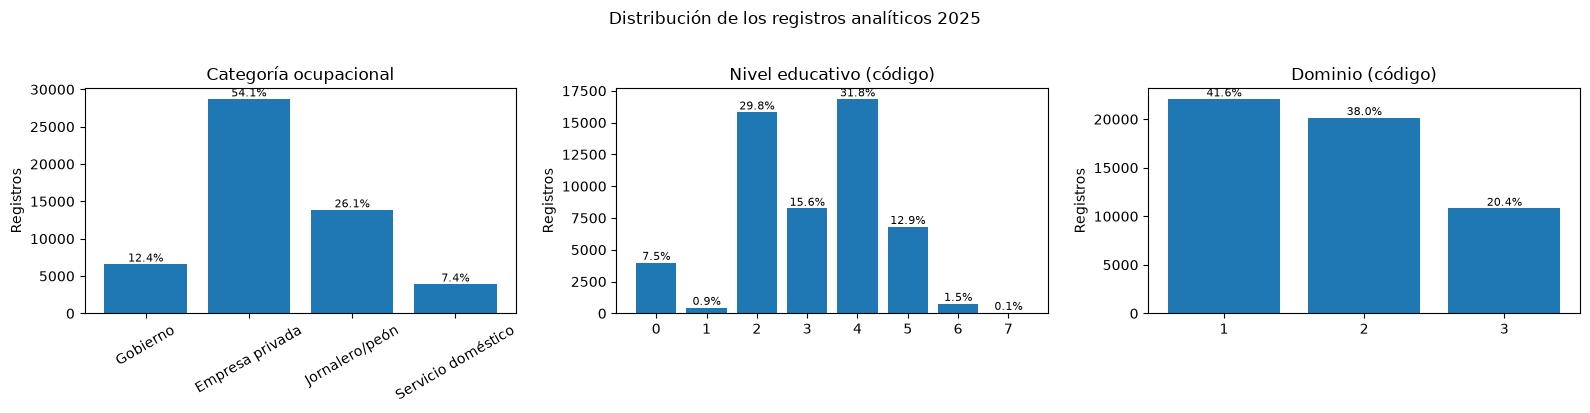

In [19]:
def muestra_pd(df, cols, n=8000, seed=SEED):
    total = df.count()
    frac = min(1.0, 1.3 * n / max(total, 1))
    return df.select(*cols).sample(False, frac, seed).limit(n).toPandas()

def ordenar_cod(idx):
    return sorted(idx, key=lambda x: (0, int(x)) if str(x).isdigit() else (1, str(x)))

# ---- Distribución de registros por categoría, nivel educativo y dominio (tablas agregadas) ----
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
for a, (col, tit) in zip(ax, [("categoria_ocupacional", "Categoría ocupacional"),
                              ("nivel_educativo", "Nivel educativo (código)"),
                              ("dominio", "Dominio (código)")]):
    t = base25.groupBy(col).count().toPandas().set_index(col)["count"]
    t = t.reindex(ordenar_cod(t.index))
    lab = [CAT_LABELS.get(i, i) if col == "categoria_ocupacional" else i for i in t.index]
    bars = a.bar(lab, t.values, color="#1f77b4")
    a.set_title(tit); a.set_ylabel("Registros")
    a.tick_params(axis="x", rotation=30 if col == "categoria_ocupacional" else 0)
    for b, v in zip(bars, t.values):
        a.text(b.get_x() + b.get_width()/2, v, f"{100*v/N25:.1f}%", ha="center", va="bottom", fontsize=8)
plt.suptitle("Distribución de los registros analíticos 2025", y=1.02); plt.tight_layout(); plt.show()

**Interpretación.** _(Complete: qué categoría ocupacional predomina —típicamente empresa privada—, qué niveles educativos concentran más registros y qué dominios están más representados. Recuerde que esto describe la muestra, no la población.)_

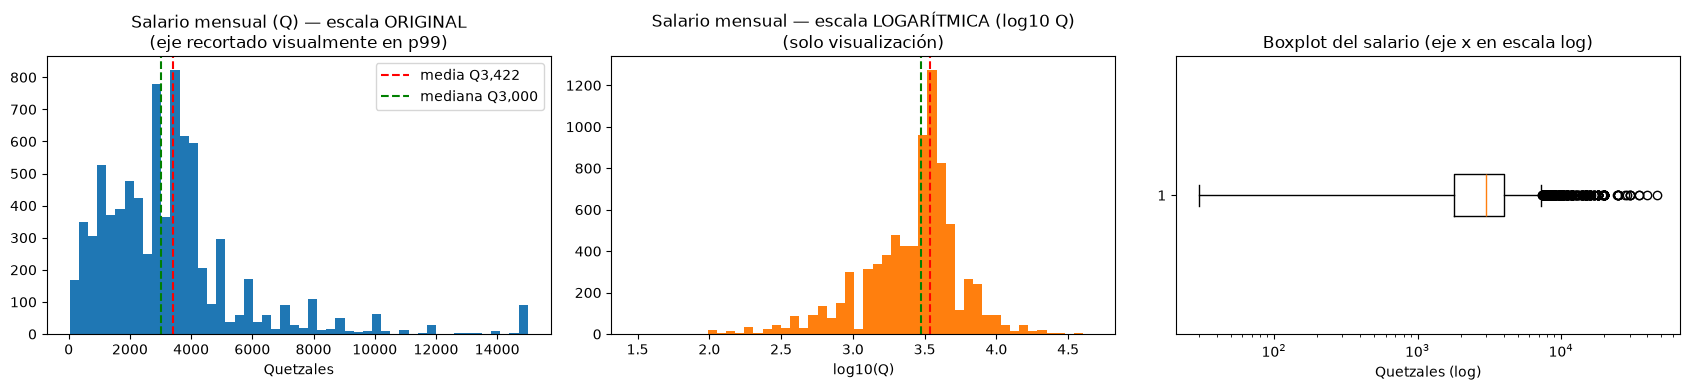

Objetivo para modelado: salario_mensual en quetzales ORIGINALES (sin transformar).


In [20]:
# ---- Distribución del salario: escala original y escala logarítmica (muestra de 8,000 solo para dibujar) ----
ms = muestra_pd(base25, ["salario_mensual"], 8000)
fig, ax = plt.subplots(1, 3, figsize=(17, 4))
p99 = base25.approxQuantile("salario_mensual", [0.99], 0.001)[0]
ax[0].hist(ms["salario_mensual"].clip(upper=p99), bins=50, color="#1f77b4")
ax[0].axvline(media_s, color="red", ls="--", label=f"media Q{media_s:,.0f}")
ax[0].axvline(med_s, color="green", ls="--", label=f"mediana Q{med_s:,.0f}")
ax[0].set_title("Salario mensual (Q) — escala ORIGINAL\n(eje recortado visualmente en p99)"); ax[0].set_xlabel("Quetzales"); ax[0].legend()
ax[1].hist(np.log10(ms["salario_mensual"]), bins=50, color="#ff7f0e")
ax[1].axvline(np.log10(media_s), color="red", ls="--"); ax[1].axvline(np.log10(med_s), color="green", ls="--")
ax[1].set_title("Salario mensual — escala LOGARÍTMICA (log10 Q)\n(solo visualización)"); ax[1].set_xlabel("log10(Q)")
ax[2].boxplot(ms["salario_mensual"], vert=False, showfliers=True); ax[2].set_xscale("log")
ax[2].set_title("Boxplot del salario (eje x en escala log)"); ax[2].set_xlabel("Quetzales (log)")
plt.tight_layout(); plt.show()
print("Objetivo para modelado: salario_mensual en quetzales ORIGINALES (sin transformar).")

**Interpretación.** _(Complete: ¿simétrica o asimétrica? La asimetría positiva y media > mediana indican cola derecha por pocos salarios altos. Explique qué implica para modelos que minimizan error cuadrático —RMSE sensible a extremos— y por qué los salarios extremos **no** se eliminan en la evaluación principal, aunque se discute su influencia.)_

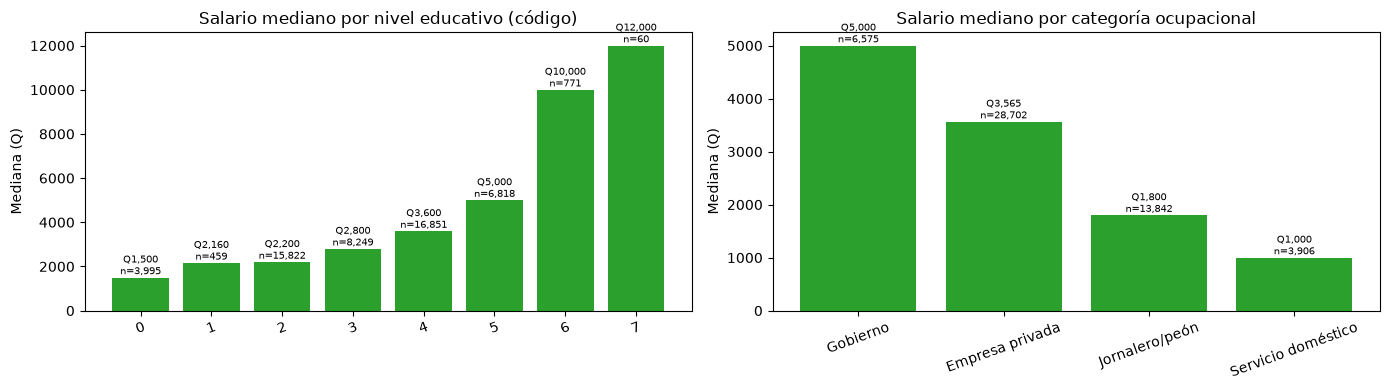

,n,mediana,media
nivel_educativo,,,
0,3995,1500.0,1767.0
1,459,2160.0,2242.0
2,15822,2200.0,2308.0
3,8249,2800.0,2730.0
4,16851,3600.0,3796.0
5,6818,5000.0,5965.0
6,771,10000.0,11409.0
7,60,12000.0,14452.0


,n,mediana,media
Gobierno,6575,5000.0,5972.0
Empresa privada,28702,3565.0,3875.0
Jornalero/peón,13842,1800.0,1879.0
Servicio doméstico,3906,1000.0,1266.0


In [21]:
# ---- Salario mediano por nivel educativo y por categoría ocupacional ----
med_expr = F.expr("percentile_approx(salario_mensual, 0.5, 100000)")
def mediana_por(col):
    t = (base25.groupBy(col).agg(F.count("*").alias("n"), med_expr.alias("mediana"),
                                 F.mean("salario_mensual").alias("media")).toPandas().set_index(col))
    return t.reindex(ordenar_cod(t.index))

med_niv, med_cat = mediana_por("nivel_educativo"), mediana_por("categoria_ocupacional")
med_cat.index = [CAT_LABELS.get(i, i) for i in med_cat.index]
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
for a, t, tit in [(ax[0], med_niv, "Nivel educativo (código)"), (ax[1], med_cat, "Categoría ocupacional")]:
    bars = a.bar(t.index.astype(str), t["mediana"], color="#2ca02c")
    a.set_title(f"Salario mediano por {tit.lower()}"); a.set_ylabel("Mediana (Q)")
    a.tick_params(axis="x", rotation=20)
    for b, v, n in zip(bars, t["mediana"], t["n"]):
        a.text(b.get_x() + b.get_width()/2, v, f"Q{v:,.0f}\nn={n:,}", ha="center", va="bottom", fontsize=7)
plt.tight_layout(); plt.show()
display(med_niv.round(0)); display(med_cat.round(0))

**Interpretación.** _(Complete: ¿el salario mediano crece con el nivel educativo? ¿Qué categorías ocupacionales ganan más/menos y con cuántos registros? Cuidado con grupos con n pequeño y con confundir asociación con causalidad.)_

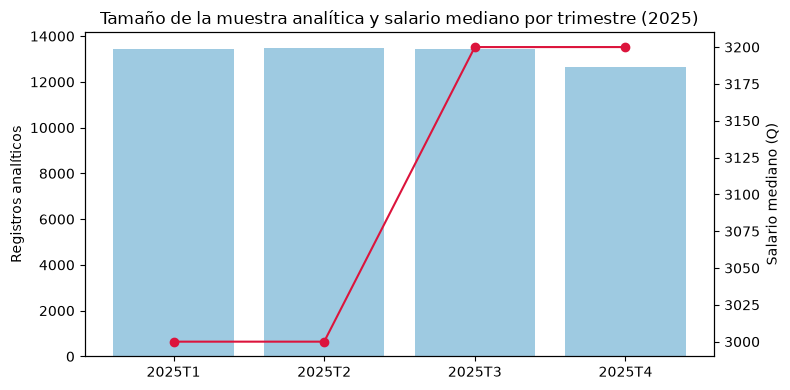

,periodo_archivo,n,mediana_salario,media_salario
0,2025T1,13419,3000.0,3315.6
1,2025T2,13492,3000.0,3364.6
2,2025T3,13450,3200.0,3469.1
3,2025T4,12664,3200.0,3544.6


In [22]:
# ---- Tamaño de muestra analítica y salario mediano por trimestre ----
tri = (base25.groupBy("periodo_archivo").agg(F.count("*").alias("n"), med_expr.alias("mediana_salario"),
                                             F.mean("salario_mensual").alias("media_salario"))
             .orderBy("periodo_archivo").toPandas())
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(tri["periodo_archivo"], tri["n"], color="#9ecae1"); ax.set_ylabel("Registros analíticos")
ax2 = ax.twinx(); ax2.plot(tri["periodo_archivo"], tri["mediana_salario"], "o-", color="crimson"); ax2.set_ylabel("Salario mediano (Q)")
ax.set_title("Tamaño de la muestra analítica y salario mediano por trimestre (2025)")
plt.tight_layout(); plt.show()
tri.round(1)

**Interpretación.** _(Complete: ¿cambia el tamaño de la muestra entre trimestres? ¿Se mueve el salario mediano? Recuerde que rotación de la muestra, salario mínimo y estacionalidad pueden influir; no se debe leer como tendencia causal.)_

---
## 3. Relaciones entre variables numéricas
Correlación de **Pearson** con `VectorAssembler` + `Correlation.corr()` sobre **todos** los registros elegibles de 2025. Se agrega **Spearman** (correlación por rangos) como complemento porque el salario es muy asimétrico y Pearson es sensible a valores extremos.

Pearson


,Salario,Edad,Antigüedad,Horas sem.
Salario,1.000,0.147,0.180,0.076
Edad,0.147,1.000,0.487,-0.105
Antigüedad,0.180,0.487,1.000,-0.062
Horas sem.,0.076,-0.105,-0.062,1.000


Spearman


,Salario,Edad,Antigüedad,Horas sem.
Salario,1.000,0.153,0.261,0.143
Edad,0.153,1.000,0.419,-0.120
Antigüedad,0.261,0.419,1.000,-0.048
Horas sem.,0.143,-0.120,-0.048,1.000


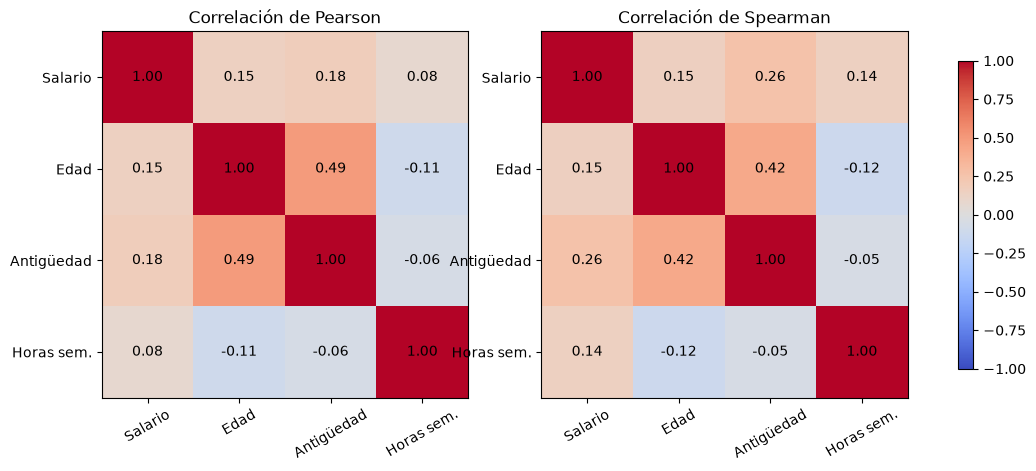

In [23]:
VARS_CORR = ["salario_mensual", "edad", "antiguedad", "horas_semanales"]
ETIQ = ["Salario", "Edad", "Antigüedad", "Horas sem."]
vec = VectorAssembler(inputCols=VARS_CORR, outputCol="v").transform(base25.select(*VARS_CORR)).select("v")

def matriz_corr(metodo):
    m = Correlation.corr(vec, "v", metodo).head()[0].toArray()
    return pd.DataFrame(m, index=ETIQ, columns=ETIQ)

corr_p, corr_s = matriz_corr("pearson"), matriz_corr("spearman")
print("Pearson"); display(corr_p.round(3))
print("Spearman"); display(corr_s.round(3))

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for a, m, t in [(ax[0], corr_p, "Pearson"), (ax[1], corr_s, "Spearman")]:
    im = a.imshow(m.values, cmap="coolwarm", vmin=-1, vmax=1)
    a.set_xticks(range(4)); a.set_xticklabels(ETIQ, rotation=30); a.set_yticks(range(4)); a.set_yticklabels(ETIQ)
    for i in range(4):
        for j in range(4):
            a.text(j, i, f"{m.values[i,j]:.2f}", ha="center", va="center", color="black")
    a.set_title(f"Correlación de {t}")
fig.colorbar(im, ax=ax, shrink=0.8); plt.show()

In [24]:
otros = corr_p.loc["Salario", ["Edad", "Antigüedad", "Horas sem."]]
print("Mayor asociación lineal con el salario (Pearson):", otros.abs().idxmax(), f"(r = {otros[otros.abs().idxmax()]:.3f})")
print(f"Correlación edad–antigüedad: Pearson = {corr_p.loc['Edad','Antigüedad']:.3f} | Spearman = {corr_s.loc['Edad','Antigüedad']:.3f}")

Mayor asociación lineal con el salario (Pearson): Antigüedad (r = 0.180)
Correlación edad–antigüedad: Pearson = 0.487 | Spearman = 0.419


**Interpretación.** _(Complete con los números de arriba.)_
- **¿Qué variable se asocia más con el salario?** _(variable, signo y magnitud; comparar Pearson vs Spearman; una |r| baja indica poca relación **lineal**, no ausencia de relación.)_
- **¿Existe relación entre edad y antigüedad?** _(esperable positiva: quien tiene más edad puede acumular más años en el empleo, y por construcción antigüedad ≤ edad; comentar posible multicolinealidad para el modelo lineal.)_
- Correlación no implica causalidad.

---
## 4. Segmentación de perfiles mediante KMeans
**Escenarios comparados** (todas las variables se **estandarizan** con `StandardScaler` con media y desviación):
- **A:** `edad`, `antiguedad`, `horas_semanales` (perfil laboral sin salario).
- **B:** A + `salario_mensual` en quetzales.
- **C:** A + `log(salario_mensual)` (para atenuar la cola derecha).

Se evalúa K = 2, 3, 4, 5 con **coeficiente de silueta** (mayor = mejor; `ClusteringEvaluator`, distancia euclidiana al cuadrado) y **costo intra-cluster (WSSSE)** para el criterio del codo. *Nota:* las siluetas de escenarios con distinto número de variables no son estrictamente comparables entre sí; se usan sobre todo para elegir K dentro de cada escenario.

In [25]:
base25_k = base25.withColumn("log_salario", F.log("salario_mensual"))
ESCENARIOS = {
    "A: sin salario":   ["edad", "antiguedad", "horas_semanales"],
    "B: con salario":   ["edad", "antiguedad", "horas_semanales", "salario_mensual"],
    "C: con log(salario)": ["edad", "antiguedad", "horas_semanales", "log_salario"],
}
KS = [2, 3, 4, 5]
evaluador = ClusteringEvaluator(featuresCol="features", predictionCol="cluster",
                                metricName="silhouette", distanceMeasure="squaredEuclidean")

def preparar_features(df, cols):
    pipe = Pipeline(stages=[VectorAssembler(inputCols=cols, outputCol="raw"),
                            StandardScaler(inputCol="raw", outputCol="features", withMean=True, withStd=True)]).fit(df)
    return pipe, pipe.transform(df).cache()

resultados, modelos, datos = [], {}, {}
for nombre, cols in ESCENARIOS.items():
    pipe, data = preparar_features(base25_k, cols)
    datos[nombre] = (pipe, data)
    for k in KS:
        m = KMeans(k=k, seed=SEED, maxIter=50, featuresCol="features", predictionCol="cluster").fit(data)
        sil = evaluador.evaluate(m.transform(data))
        tam = sorted(m.summary.clusterSizes, reverse=True)
        resultados.append({"escenario": nombre, "K": k, "silueta": round(sil, 4),
                           "WSSSE": round(m.summary.trainingCost, 1),
                           "cluster_mas_pequeño_%": round(100 * min(tam) / N25, 1)})
        modelos[(nombre, k)] = m
res_k = pd.DataFrame(resultados)
display(res_k.pivot(index="K", columns="escenario", values="silueta"))
display(res_k)

escenario,A: sin salario,B: con salario,C: con log(salario)
K,,,
2,0.5545,0.5148,0.4707
3,0.4718,0.3372,0.4753
4,0.4761,0.3753,0.3722
5,0.4840,0.3884,0.3874


,escenario,K,silueta,WSSSE,cluster_mas_pequeño_%
0,A: sin salario,2,0.5545,106717.4,27.5
1,A: sin salario,3,0.4718,83608.0,19.1
2,A: sin salario,4,0.4761,64438.2,13.0
3,A: sin salario,5,0.4840,54990.4,11.7
4,B: con salario,2,0.5148,157345.6,27.0
5,B: con salario,3,0.3372,133003.2,16.7
6,B: con salario,4,0.3753,113688.2,4.4
7,B: con salario,5,0.3884,106301.4,0.6
8,C: con log(salario),2,0.4707,159174.1,28.2
9,C: con log(salario),3,0.4753,125145.2,17.6


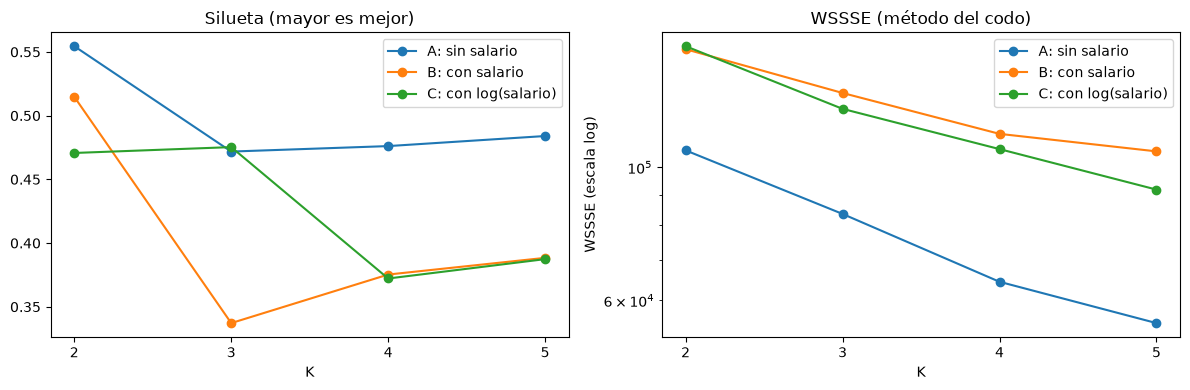

In [26]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for nombre in ESCENARIOS:
    t = res_k[res_k["escenario"] == nombre]
    ax[0].plot(t["K"], t["silueta"], "o-", label=nombre); ax[1].plot(t["K"], t["WSSSE"], "o-", label=nombre)
ax[0].set_title("Silueta (mayor es mejor)"); ax[1].set_title("WSSSE (método del codo)")
for a in ax: a.set_xlabel("K"); a.set_xticks(KS); a.legend()
ax[1].set_yscale("log"); ax[1].set_ylabel("WSSSE (escala log)")
plt.tight_layout(); plt.show()

**Interpretación.** _(Complete: ¿qué K maximiza la silueta en cada escenario? ¿Hay un codo claro en WSSSE? ¿El escenario B (salario en Q) queda dominado por los salarios extremos, con clusters diminutos? ¿Vale la pena incluir salario?)_

**Criterio del grupo.** El K se elige con la **máxima silueta** dentro del escenario elegido, exigiendo que ningún cluster sea trivial (≥ 5 % de los registros) para que los perfiles sean interpretables; si K=2 gana por poco pero K mayor da perfiles más informativos, se justifica por escrito en el markdown. Como el salario es el objetivo del modelado posterior, la **recomendación por defecto** es segmentar con el escenario A (perfil laboral) y **usar el salario después para describir** cada cluster; cambie `ESCENARIO_FINAL` si sus resultados sugieren otra cosa.

In [27]:
ESCENARIO_FINAL = "A: sin salario"      # <- editable según su análisis
t = res_k[(res_k["escenario"] == ESCENARIO_FINAL) & (res_k["cluster_mas_pequeño_%"] >= 5)]
K_FINAL = int(t.sort_values("silueta", ascending=False).iloc[0]["K"])
print(f"Escenario final: {ESCENARIO_FINAL} | K elegido por silueta (clusters >= 5%): {K_FINAL}")

pipe_f, data_f = datos[ESCENARIO_FINAL]
modelo_f = modelos[(ESCENARIO_FINAL, K_FINAL)]
asignado = modelo_f.transform(data_f)          # incluye columna 'cluster'
asignado = asignado.select("cluster", "edad", "antiguedad", "horas_semanales", "salario_mensual",
                           "categoria_ocupacional", "nivel_educativo", "dominio").cache()

Escenario final: A: sin salario | K elegido por silueta (clusters >= 5%): 2


In [28]:
# ---- Perfil de cada cluster ----
perf = (asignado.groupBy("cluster").agg(
    F.count("*").alias("n"),
    F.round(F.mean("edad"), 1).alias("edad_media"),
    F.round(F.mean("antiguedad"), 1).alias("antig_media"),
    F.round(F.mean("horas_semanales"), 1).alias("horas_media"),
    F.round(F.expr("percentile_approx(salario_mensual, 0.5, 100000)"), 0).alias("salario_mediano"),
    F.round(F.mean("salario_mensual"), 0).alias("salario_medio")).orderBy("cluster").toPandas().set_index("cluster"))
perf["pct_registros"] = (100 * perf["n"] / N25).round(1)

comp = (asignado.groupBy("cluster", "categoria_ocupacional").count().toPandas()
        .pivot(index="cluster", columns="categoria_ocupacional", values="count").fillna(0))
comp = (100 * comp.div(comp.sum(axis=1), axis=0)).round(1).rename(columns={k: f"%{CAT_LABELS.get(k,k)}" for k in comp.columns})
perf = perf.join(comp)
display(perf)

# Descripción automática de apoyo (comparación contra la media global)
g = base25.agg(F.mean("edad"), F.stddev("edad"), F.mean("antiguedad"), F.stddev("antiguedad"),
               F.mean("horas_semanales"), F.stddev("horas_semanales")).first()
gm = {"edad": (g[0], g[1]), "antig": (g[2], g[3]), "horas": (g[4], g[5])}
def nivel(v, m, s):
    z = (v - m) / s
    return "alta" if z > 0.5 else "baja" if z < -0.5 else "media"
print("\nBorrador de descripción (edítelo con su interpretación):")
for c, r in perf.iterrows():
    print(f"Cluster {c} (n={int(r['n']):,}, {r['pct_registros']}%): edad {nivel(r['edad_media'], *gm['edad'])} ({r['edad_media']} a), "
          f"antigüedad {nivel(r['antig_media'], *gm['antig'])} ({r['antig_media']} a), "
          f"jornada {nivel(r['horas_media'], *gm['horas'])} ({r['horas_media']} h), salario mediano Q{r['salario_mediano']:,.0f}")

,n,edad_media,antig_media,horas_media,salario_mediano,salario_medio,pct_registros,%Gobierno,%Empresa privada,%Jornalero/peón,%Servicio doméstico
cluster,,,,,,,,,,,
0,38421,29.1,2.4,48.2,3000.0,3176.0,72.5,8.2,58.5,26.8,6.5
1,14604,51.3,13.8,41.3,3466.0,4069.0,27.5,23.5,42.5,24.3,9.7



Borrador de descripción (edítelo con su interpretación):
Cluster 0 (n=38,421, 72.5%): edad media (29.1 a), antigüedad media (2.4 a), jornada media (48.2 h), salario mediano Q3,000
Cluster 1 (n=14,604, 27.5%): edad alta (51.3 a), antigüedad alta (13.8 a), jornada media (41.3 h), salario mediano Q3,466


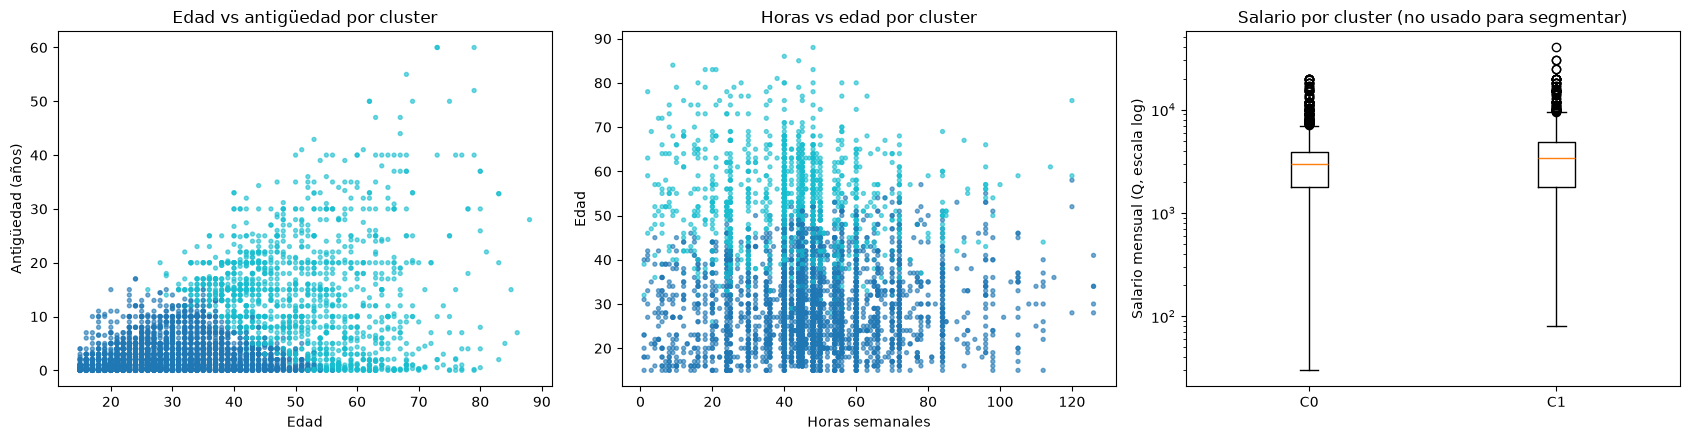

In [30]:
# ---- Visualización (muestra de 5,000 registros solo para dibujar) ----
ms = muestra_pd(asignado, ["cluster", "edad", "antiguedad", "horas_semanales", "salario_mensual"], 5000)
fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))
sc = ax[0].scatter(ms["edad"], ms["antiguedad"], c=ms["cluster"], cmap="tab10", s=8, alpha=0.6)
ax[0].set_xlabel("Edad"); ax[0].set_ylabel("Antigüedad (años)"); ax[0].set_title("Edad vs antigüedad por cluster")
ax[1].scatter(ms["horas_semanales"], ms["edad"], c=ms["cluster"], cmap="tab10", s=8, alpha=0.6)
ax[1].set_xlabel("Horas semanales"); ax[1].set_ylabel("Edad"); ax[1].set_title("Horas vs edad por cluster")
datos_box = [ms.loc[ms["cluster"] == c, "salario_mensual"] for c in sorted(ms["cluster"].unique())]
ax[2].boxplot(datos_box, tick_labels=[f"C{c}" for c in sorted(ms["cluster"].unique())]); ax[2].set_yscale("log")
ax[2].set_ylabel("Salario mensual (Q, escala log)"); ax[2].set_title("Salario por cluster (no usado para segmentar)")
plt.tight_layout(); plt.show()

**Descripción de los clusters.** _(Complete usando la tabla de perfiles y los gráficos. Asigne a cada cluster un nombre y una descripción basada en sus resultados, por ejemplo:_
- _Cluster 0 – "…": edad media …, antigüedad …, jornada …, salario mediano Q…, composición ocupacional …_
- _Cluster 1 – "…": …_

_Discuta también: ¿los clusters se separan más por edad/antigüedad o por horas? ¿el salario (no usado para segmentar) difiere entre clusters? ¿es útil incluir salario en la segmentación? Recuerde que es aprendizaje no supervisado: los clusters son perfiles descriptivos, no categorías "reales", y dependen de las variables y del K elegidos._)

---
### Resumen del avance
Se generaron: `personas_2025_preparado.parquet` y `personas_2026_preparado.parquet`, tablas de calidad de datos, estadística descriptiva, matriz de correlación y una segmentación KMeans. La sección de modelado (regresión lineal, Random Forest, evaluación en 2026 y análisis de errores) parte de estos Parquet.